In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import netCDF4 as nc
import xarray as xr
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.dates as mdates

import sys
sys.path.append("functions") 
from functions import doppio, doppio_pipeliner, axis_ratio_from_Q, tangential_velocity, out_core_param_fit, model_uv_at_xy, vector_R2   


### Numerical Data

In [2]:
ssh_path = 'data/gridded_numerical_data.nc'
ds_nc = nc.Dataset(ssh_path)

lon, lat = ds_nc['longitude'][:], ds_nc['latitude'][:]
u = np.squeeze(ds_nc['uo'][:]); v = np.squeeze(ds_nc['vo'][:])
# u, v = np.transpose(u, (2,1,0)), np.transpose(v, (2,1,0))  # (time, lat, lon)
t = pd.Timestamp("1950-01-01") + pd.to_timedelta(ds_nc['time'][:], "h")
u, v = np.where(np.abs(u) < 100, u, np.nan), np.where(np.abs(v) < 100, v, np.nan)
lon2d, lat2d = np.meshgrid(lon, lat, indexing="xy")
theta_mean, phi_mean = 154.3, -37.9
x = (lon2d-theta_mean)*111000*np.cos(np.deg2rad(phi_mean))
y = (lat2d-phi_mean)*111000
ds_cop = xr.Dataset(
    {"u": (("time","lat","lon"), u),
     "v": (("time","lat","lon"), v)},
    coords={"time": t, "lat": lat, "lon": lon,
            "x": (("lat","lon"), x),
            "y": (("lat","lon"), y)}
)
ds_cop["land_mask"] = np.isnan(ds_cop.u.isel(time=0)) & np.isnan(ds_cop.v.isel(time=0))
# # Time slice
ds_cop = ds_cop.sel(time=ds_cop.time <= np.datetime64('2024-01-27T00:00:00.000000000'))

ds_cop


<xarray.Dataset> Size: 9MB
Dimensions:    (time: 101, lat: 97, lon: 109)
Coordinates:
  * time       (time) datetime64[ns] 808B 2023-10-19 ... 2024-01-27
  * lat        (lat) float32 388B -42.0 -41.92 -41.83 ... -34.17 -34.08 -34.0
  * lon        (lon) float32 436B 149.0 149.1 149.2 149.2 ... 157.8 157.9 158.0
    x          (lat, lon) float64 85kB -4.642e+05 -4.569e+05 ... 3.241e+05
    y          (lat, lon) float64 85kB -4.551e+05 -4.551e+05 ... 4.329e+05
Data variables:
    u          (time, lat, lon) float32 4MB -0.284 -0.3366 ... 0.3254 0.346
    v          (time, lat, lon) float32 4MB -0.2342 -0.1941 ... -0.1586 -0.1242
    land_mask  (lat, lon) bool 11kB False False False ... False False False

#### Calculate inner-core ESP parameters

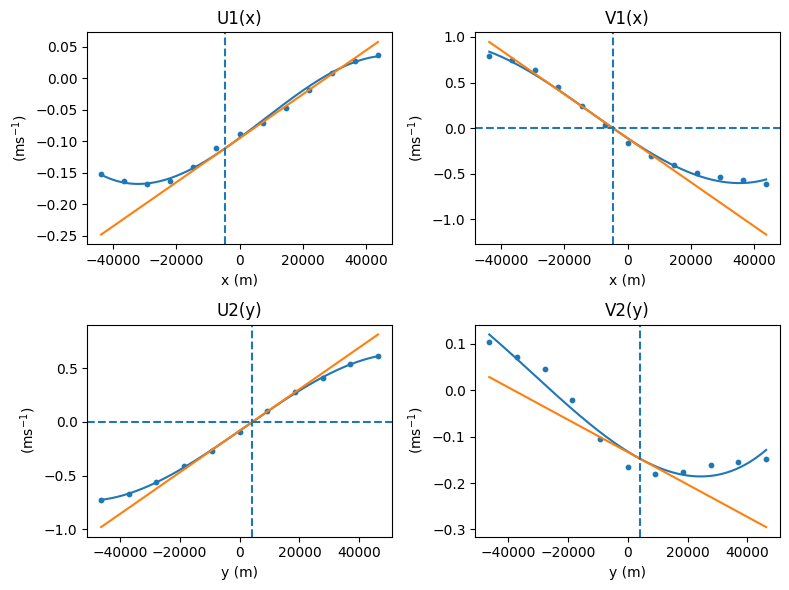

,xc,yc,w,Q,Omega,time,alpha
0,-5125.095355,-797.697475,-0.000040,"[[1.0292421327325185, -0.09274719301104836], [...",-0.000020,2023-10-19 00:00:00,1.100561
1,-3471.649313,291.793634,-0.000041,"[[0.9685311171766586, -0.09217048259706591], [...",-0.000020,2023-10-19 23:56:15,1.103982
2,-7756.218779,-5434.595588,-0.000041,"[[0.92486914104395, -0.11936775324512824], [-0...",-0.000020,2023-10-21 00:00:00,1.157809
3,-3099.643663,-4604.936556,-0.000042,"[[0.8962093241916665, -0.12740320203928893], [...",-0.000021,2023-10-22 00:00:00,1.189302
4,-628.950631,-4833.080558,-0.000041,"[[0.8196407793344359, -0.056223671837836185], ...",-0.000020,2023-10-22 23:56:15,1.231577
...,...,...,...,...,...,...,...
96,-251761.221804,167749.846372,-0.000026,"[[1.194097564291838, 0.013789833203115873], [0...",-0.000013,2024-01-23 00:00:00,1.194630
97,-254769.682875,162518.463332,-0.000018,"[[1.5074853843445863, -0.21726772870890168], [...",-0.000008,2024-01-24 00:00:00,1.561917
98,-270172.123673,154268.416478,-0.000017,"[[1.2728191361593584, -0.45121890347086907], [...",-0.000008,2024-01-25 00:00:00,1.589180
99,-261663.662651,166086.561707,-0.000017,"[[1.230046502322559, -0.4985208332297986], [-0...",-0.000008,2024-01-26 00:00:00,1.632516


In [3]:
xc_pre, yc_pre = 0.0, 0.0
rows = []
xyuv_rows = []

X = ds_cop.x.values
Y = ds_cop.y.values

for t, time in enumerate(ds_cop.time.values):
    ut = ds_cop.u.sel(time=time).values
    vt = ds_cop.v.sel(time=time).values

    x1,y1,u1,v1,x2,y2,u2,v2 = doppio_pipeliner(xc_pre, yc_pre, ut.T, vt.T, X.T, Y.T, r=50_000)
    xc, yc, w, Q, Omega = doppio(x1,y1,u1,v1,x2,y2,u2,v2, plot=True if t == 10 else False)

    ok = (np.isfinite(xc) and np.isfinite(yc) and
          (np.hypot(xc-xc_pre, yc-yc_pre) < 100_000) and (w < 0))

    if not ok:
        break

    rows.append(dict(xc=xc, yc=yc, w=w, Q=Q, Omega=Omega, time=time))
    xc_pre, yc_pre = xc, yc

    xi = np.concatenate([x1, x2])
    yi = np.concatenate([y1, y2])
    ui = np.concatenate([u1, u2])
    vi = np.concatenate([v1, v2])

    xyuv_rows.append(pd.DataFrame({
        "time": time,
        "core": "inner",
        "xi": xi, "yi": yi, "ui": ui, "vi": vi
    }))

df_res = pd.DataFrame(rows, columns=["xc","yc","w","Q","Omega","time"])
df_res["alpha"] = [axis_ratio_from_Q(Q) for Q in df_res["Q"].to_list()]

df_xyuv = pd.concat(xyuv_rows, ignore_index=True) if xyuv_rows else pd.DataFrame(
    columns=["time","core","xi","yi","ui","vi"]
)

df_res


#### Calculate outer-core ESP parameters

,xc,yc,w,Q,Omega,time,alpha,Rc,psi0
0,-5125.095355,-797.697475,-0.000036,"[[1.0292421327325185, -0.09274719301104836], [...",-0.000018,2023-10-19 00:00:00,1.100561,84171.005782,63147.724488
1,-3471.649313,291.793634,-0.000036,"[[0.9685311171766586, -0.09217048259706591], [...",-0.000018,2023-10-19 23:56:15,1.103982,83629.253531,62598.430571
2,-7756.218779,-5434.595588,-0.000036,"[[0.92486914104395, -0.11936775324512824], [-0...",-0.000018,2023-10-21 00:00:00,1.157809,84719.695665,63222.726367
3,-3099.643663,-4604.936556,-0.000037,"[[0.8962093241916665, -0.12740320203928893], [...",-0.000018,2023-10-22 00:00:00,1.189302,83102.656004,62914.481175
4,-628.950631,-4833.080558,-0.000037,"[[0.8196407793344359, -0.056223671837836185], ...",-0.000018,2023-10-22 23:56:15,1.231577,82764.124382,62456.381434
...,...,...,...,...,...,...,...,...,...
96,-251761.221804,167749.846372,-0.000035,"[[1.194097564291838, 0.013789833203115873], [0...",-0.000017,2024-01-23 00:00:00,1.194630,62132.835961,33044.661076
97,-254769.682875,162518.463332,-0.000033,"[[1.5074853843445863, -0.21726772870890168], [...",-0.000015,2024-01-24 00:00:00,1.561917,65992.369414,32417.778192
98,-270172.123673,154268.416478,-0.000028,"[[1.2728191361593584, -0.45121890347086907], [...",-0.000013,2024-01-25 00:00:00,1.589180,71211.892835,32145.920154
99,-261663.662651,166086.561707,-0.000023,"[[1.230046502322559, -0.4985208332297986], [-0...",-0.000010,2024-01-26 00:00:00,1.632516,79683.435656,31916.538718


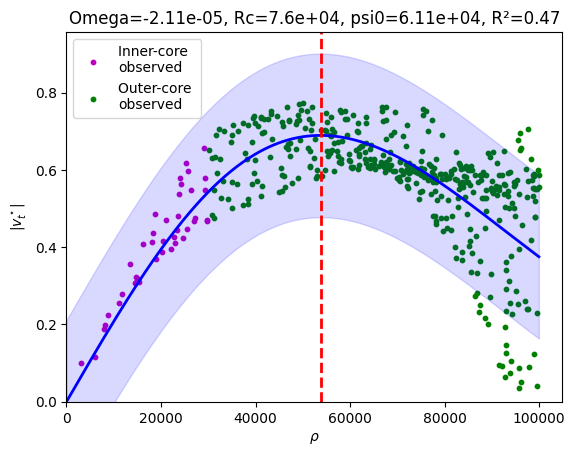

In [4]:
rho_outer = 100_000.0

xi0 = ds_cop.x.values.ravel()
yi0 = ds_cop.y.values.ravel()

Rc_opts, psi0_opts, Omega_opts = [], [], []
xyuv_rows = []

for k, data in df_res.iterrows():
    time = data.time

    ui0 = ds_cop.u.sel(time=time).values.ravel()
    vi0 = ds_cop.v.sel(time=time).values.ravel()

    xc, yc = float(data.xc), float(data.yc)
    Q = np.asarray(data.Q)
    Omega = float(data.Omega)
    q11, q12, q22 = Q[0,0], Q[0,1], Q[1,1]

    dx = xi0 - xc
    dy = yi0 - yc
    rho2 = q11*dx*dx + 2*q12*dx*dy + q22*dy*dy

    outer = rho2 <= rho_outer**2
    xi_o, yi_o = xi0[outer], yi0[outer]
    ui_o, vi_o = ui0[outer], vi0[outer]

    xyuv_rows.append(pd.DataFrame({
        "time": time, "core": "outer",
        "xi": xi_o, "yi": yi_o, "ui": ui_o, "vi": vi_o
    }))

    Rc_opt, psi0_opt, Omega_opt = out_core_param_fit(xi_o, yi_o, ui_o, vi_o, xc, yc, Q, Omega0=Omega, plot=(k == 10), pred_flag=True)

    Rc_opts.append(Rc_opt); psi0_opts.append(psi0_opt); Omega_opts.append(Omega_opt)

df_xyuv_o = pd.concat(xyuv_rows, ignore_index=True) if xyuv_rows else pd.DataFrame(
    columns=["time","core","xi","yi","ui","vi"]
)

df_xyuv = pd.concat([df_xyuv, df_xyuv_o], ignore_index=True)
df_xyuv = (
    df_xyuv
    .sort_values(by="core", key=lambda s: s.eq("outer"))  # keep inner first
    .drop_duplicates(subset=["time", "xi", "yi", "ui", "vi"], keep="first")
    .reset_index(drop=True)
)

df_res["Rc"] = Rc_opts
df_res["psi0"] = psi0_opts
df_res["Omega"] = Omega_opts
df_res["w"] = [Omega*(Q[0,0] + Q[1,1]) for (Omega,Q) in zip(df_res.Omega, df_res.Q)]
df_res


In [5]:
# find (i,j) indices of sampled data
df = df_xyuv.copy()

xg = ds_cop.x[0, :].values
yg = ds_cop.y[:, 0].values
xi = df["xi"].to_numpy()
yi = df["yi"].to_numpy()
i = np.searchsorted(xg, xi)
i = np.clip(i, 1, len(xg) - 1)
i -= (xi - xg[i - 1] < xg[i] - xi)
j = np.searchsorted(yg, yi)
j = np.clip(j, 1, len(yg) - 1)
j -= (yi - yg[j - 1] < yg[j] - yi)
df["i"] = i
df["j"] = j

df_xyuv = df


In [6]:
# Find R2
R2_vals = []
for _, row in df_res.iterrows():
    df = df_xyuv[df_xyuv.time == row.time]
    xi = df.xi.to_numpy(float)
    yi = df.yi.to_numpy(float)
    u  = df.ui.to_numpy(float)
    v  = df.vi.to_numpy(float)
    uhat, vhat = model_uv_at_xy(xi, yi, row.xc, row.yc, np.asarray(row.Q), row.Omega, row.Rc)
    R2_vals.append(vector_R2(u, v, uhat, vhat))
df_res['R2'] = R2_vals
df_res


,xc,yc,w,Q,Omega,time,alpha,Rc,psi0,R2
0,-5125.095355,-797.697475,-0.000036,"[[1.0292421327325185, -0.09274719301104836], [...",-0.000018,2023-10-19 00:00:00,1.100561,84171.005782,63147.724488,0.941040
1,-3471.649313,291.793634,-0.000036,"[[0.9685311171766586, -0.09217048259706591], [...",-0.000018,2023-10-19 23:56:15,1.103982,83629.253531,62598.430571,0.953327
2,-7756.218779,-5434.595588,-0.000036,"[[0.92486914104395, -0.11936775324512824], [-0...",-0.000018,2023-10-21 00:00:00,1.157809,84719.695665,63222.726367,0.922006
3,-3099.643663,-4604.936556,-0.000037,"[[0.8962093241916665, -0.12740320203928893], [...",-0.000018,2023-10-22 00:00:00,1.189302,83102.656004,62914.481175,0.950188
4,-628.950631,-4833.080558,-0.000037,"[[0.8196407793344359, -0.056223671837836185], ...",-0.000018,2023-10-22 23:56:15,1.231577,82764.124382,62456.381434,0.954496
...,...,...,...,...,...,...,...,...,...,...
96,-251761.221804,167749.846372,-0.000035,"[[1.194097564291838, 0.013789833203115873], [0...",-0.000017,2024-01-23 00:00:00,1.194630,62132.835961,33044.661076,0.409838
97,-254769.682875,162518.463332,-0.000033,"[[1.5074853843445863, -0.21726772870890168], [...",-0.000015,2024-01-24 00:00:00,1.561917,65992.369414,32417.778192,0.518784
98,-270172.123673,154268.416478,-0.000028,"[[1.2728191361593584, -0.45121890347086907], [...",-0.000013,2024-01-25 00:00:00,1.589180,71211.892835,32145.920154,0.372785
99,-261663.662651,166086.561707,-0.000023,"[[1.230046502322559, -0.4985208332297986], [-0...",-0.000010,2024-01-26 00:00:00,1.632516,79683.435656,31916.538718,0.437447


In [7]:
# Reconstruct velocity field using ESP parameters
X = ds_cop.x.values
Y = ds_cop.y.values
nt = len(df_res)

U = np.empty((nt, X.shape[0], X.shape[1]))
V = np.empty((nt, X.shape[0], X.shape[1]))

for k in range(nt):
    data = df_res.iloc[k]

    dx = X - data.xc
    dy = Y - data.yc

    q11, q12, q22 = data.Q[0,0], data.Q[0,1], data.Q[1,1]

    rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2
    fac = data.Omega * np.exp(-rho2 / data.Rc**2)

    U[k] = -fac * (q12*dx + q22*dy)
    V[k] =  fac * (q11*dx + q12*dy)

mask = ds_cop.land_mask.values[None, :, :]   # (1, lat, lon)
U = np.where(mask, np.nan, U)
V = np.where(mask, np.nan, V)

ds_model = xr.Dataset(
    data_vars=dict(
        u=(("time","lat","lon"), U),
        v=(("time","lat","lon"), V),
    ),
    coords=dict(
        time=df_res.time.values,
        lat=ds_cop.lat.values,
        lon=ds_cop.lon.values,
        x=(("lat","lon"), X),
        y=(("lat","lon"), Y),
    ),
)


In [8]:
def plot_model(df_res, ds_cop, ds_model, df_xyuv, time=None, spac=1, scale=20,
                xlim=(-410, 200), ylim=(-160, 260), out_thresh=False, plot_data=False):

    if time is None:
        time = ds_model.time.values[0]

    sat = ds_cop.sel(time=time, method="nearest")
    mod = ds_model.sel(time=time, method="nearest")
    data = df_res[df_res.time == time].iloc[0]

    X = sat.x.values / 1e3
    Y = sat.y.values / 1e3

    us, vs = sat.u.values, sat.v.values
    um, vm = mod.u.values, mod.v.values

    sp_s = np.hypot(us, vs)
    sp_m = np.hypot(um, vm)

    dx, dy = sat.x.values - data.xc, sat.y.values - data.yc
    q11, q12, q22 = data.Q[0,0], data.Q[0,1], data.Q[1,1]
    rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2

    roi = (X >= xlim[0]) & (X <= xlim[1]) & (Y >= ylim[0]) & (Y <= ylim[1])
    sp_s_roi = np.where(roi, sp_s, np.nan)
    sp_m_roi = np.where(roi, sp_m, np.nan)
    roi_quiv = roi & (rho2 >= 100_000**2)

    vals = np.concatenate([sp_s_roi[roi], sp_m_roi[roi]])
    vmax = np.nanmax(vals)
    levels = np.arange(0, vmax + .05, .05)

    X_rho, Y_rho = np.meshgrid(np.linspace(xlim[0]*1e3, xlim[1]*1e3, 100),
                               np.linspace(ylim[0]*1e3, ylim[1]*1e3, 100))
    dx = X_rho - data.xc
    dy = Y_rho - data.yc
    rho2 = data.Q[0,0]*dx**2 + 2*data.Q[0,1]*dx*dy + data.Q[1,1]*dy**2

    fig, axs = plt.subplots(1, 2, figsize=(15, 8), sharex=True, sharey=True, constrained_layout=True)

    # ----- coloured center path -----
    x_path = df_res.xc.to_numpy() / 1e3
    y_path = df_res.yc.to_numpy() / 1e3
    t_path = pd.to_datetime(df_res.time)
    t_num = mdates.date2num(t_path)

    pts = np.array([x_path, y_path]).T.reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)

    norm_t = Normalize(t_num.min(), t_num.max())
    lc0 = LineCollection(segs, cmap="plasma", norm=norm_t, linewidth=2, zorder=2)
    lc0.set_array(t_num[:-1])

    lc1 = LineCollection(segs, cmap="plasma", norm=norm_t, linewidth=2, zorder=2)
    lc1.set_array(t_num[:-1])

    # ---- Numerical model ----
    h0 = axs[0].contourf(X, Y, sp_s_roi, levels=levels, cmap="Blues_r")

    axs[0].quiver(X[::spac,::spac], Y[::spac,::spac],
                  np.where(roi_quiv[::spac,::spac], us[::spac,::spac], np.nan),
                  np.where(roi_quiv[::spac,::spac], vs[::spac,::spac], np.nan),
                  scale=scale, width=.0015, alpha=.4)

    axs[0].scatter(data.xc/1e3, data.yc/1e3, marker="x", color="r", s=50, zorder=3)
    axs[0].add_collection(lc0)
    axs[0].contour(X_rho/1e3, Y_rho/1e3, rho2, levels=[(data.Rc**2)/2], colors="r", linewidths=2, linestyles='--', zorder=3)

    if plot_data:
        df = df_xyuv[(df_xyuv.time == time) & (df_xyuv.core == 'outer')]

        ni, nj = X.shape
        
        U = np.full((ni, nj), np.nan)
        V = np.full((ni, nj), np.nan)
        
        # fill grid
        U[df["j"], df["i"]] = df["ui"].values
        V[df["j"], df["i"]] = df["vi"].values
        
        axs[0].quiver(
            X[::spac, ::spac],
            Y[::spac, ::spac],
            U[::spac, ::spac],
            V[::spac, ::spac],
            scale=scale,
            width=.0025,
            color='g',
            label='Outer-core data',
            zorder=2
        )
        
        df = df_xyuv[(df_xyuv.time == time) & (df_xyuv.core == 'inner')]
        axs[0].quiver(df.xi/1e3, df.yi/1e3, df.ui, df.vi,
                      scale=scale, width=.0025, color='m', label='Transect/inner-core data', zorder=3)

    axs[0].set_aspect("equal")
    axs[0].legend(loc='lower left')

    # ---- Fitted model ----
    h1 = axs[1].contourf(X, Y, sp_m_roi, levels=levels, cmap="Blues_r")
    axs[1].quiver(X[::spac,::spac], Y[::spac,::spac],
                  np.where(roi[::spac,::spac], um[::spac,::spac], np.nan),
                  np.where(roi[::spac,::spac], vm[::spac,::spac], np.nan),
                  scale=scale, width=.0015, alpha=.5)
    axs[1].scatter(data.xc/1e3, data.yc/1e3, marker="x", color="r", s=50, label='Eddy center', zorder=3)
    axs[1].plot([np.nan, np.nan], [np.nan, np.nan], lw=2, color='r', label='Max tangential\nvelocity', ls='--')
    axs[1].add_collection(lc1)
    axs[1].contour(X_rho/1e3, Y_rho/1e3, rho2, levels=[(data.Rc**2)/2], colors="r", linewidths=2, linestyles='--', zorder=3)

    axs[1].set_aspect("equal")
    axs[1].legend(loc='lower left')

    gap = 20
    for ax in axs:
        ax.set_xlim(xlim[0] + gap, xlim[1] - gap)
        ax.set_ylim(ylim[0] + gap, ylim[1] - gap)
        ax.set_xlabel("x (km)")
    axs[0].set_ylabel("y (km)")

    axs[0].text(-0.05, 1.05, "a)", transform=axs[0].transAxes, fontsize=13, fontweight="bold", va="top", ha="left")
    axs[1].text(-0.05, 1.05, "b)", transform=axs[1].transAxes, fontsize=13, fontweight="bold", va="top", ha="left")

    # speed colourbar
    cbar1 = fig.colorbar(h1, ax=axs, label="Current speed (m s$^{-1}$)", fraction=0.0165, pad=0.02)

    # time colourbar on far right
    cbar2 = fig.colorbar(lc1, ax=axs, fraction=0.0165, pad=0.025)
    cbar2.set_label("Center path time")
    cbar2.ax.yaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))

    plt.show()


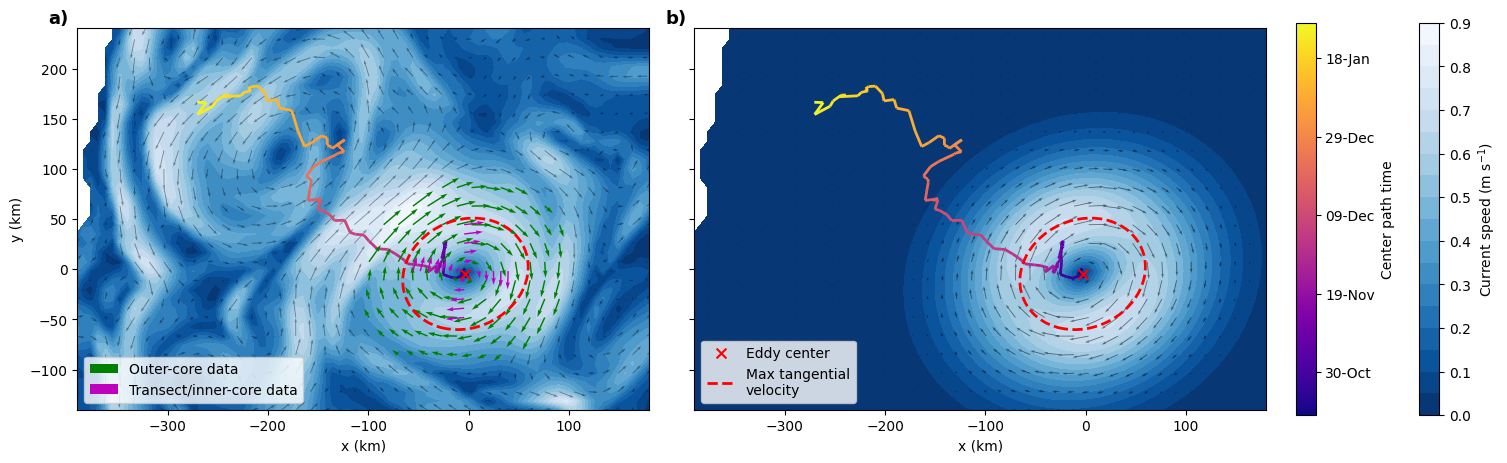

In [9]:
plot_model(df_res, ds_cop, ds_model, df_xyuv, time=df_res.time.values[3], spac=2, out_thresh=False, plot_data=True)


In [10]:
# Results
df_paper = df_res.copy()
df_paper.loc[np.arange(0, 100, 10)]


,xc,yc,w,Q,Omega,time,alpha,Rc,psi0,R2
0,-5125.095355,-797.697475,-0.000036,"[[1.0292421327325185, -0.09274719301104836], [...",-0.000018,2023-10-19 00:00:00,1.100561,84171.005782,63147.724488,0.941040
10,-25382.605432,-5023.294825,-0.000043,"[[1.130891271369642, 0.16383437087465294], [0....",-0.000021,2023-10-29 00:00:00,1.217590,76029.302811,61073.596802,0.952204
20,-24276.910359,20179.069478,-0.000040,"[[1.2459728368956542, -0.066861127197711], [-0...",-0.000020,2023-11-08 00:00:00,1.255913,78542.249873,60203.275092,0.965953
30,-30235.434528,-1614.119369,-0.000035,"[[1.1648088785759356, -0.04542828952740781], [...",-0.000017,2023-11-18 00:00:00,1.171441,94398.034774,77163.240406,0.815514
40,-51261.510782,4335.616109,-0.000035,"[[1.1041632508324886, -0.055270200749222474], ...",-0.000017,2023-11-28 00:00:00,1.118692,92464.217637,73505.357672,0.859804
50,-118126.389062,36707.129515,-0.000043,"[[1.1073205633059773, -0.14909521893701022], [...",-0.000021,2023-12-08 00:00:00,1.190477,88914.235046,83026.617439,0.774128
60,-159890.716963,69068.354498,-0.000042,"[[1.2139311512124074, -0.15213319580083226], [...",-0.000020,2023-12-17 23:56:15,1.268326,88239.182156,78875.571112,0.652245
70,-123863.457567,117057.075954,-0.000048,"[[0.5715508046008112, -0.1691379367241149], [-...",-0.000020,2023-12-28 00:00:00,1.822546,79914.958783,64029.881221,0.541893
80,-163497.756021,122343.240224,-0.000032,"[[1.7605473668391782, -0.17103506315053485], [...",-0.000014,2024-01-07 00:00:00,1.784919,103019.942225,72703.854077,0.769879
90,-216926.929893,177851.732792,-0.000044,"[[0.6670247936905995, -0.07126182057067978], [...",-0.000020,2024-01-17 00:00:00,1.512812,64473.783282,41684.645967,0.762035


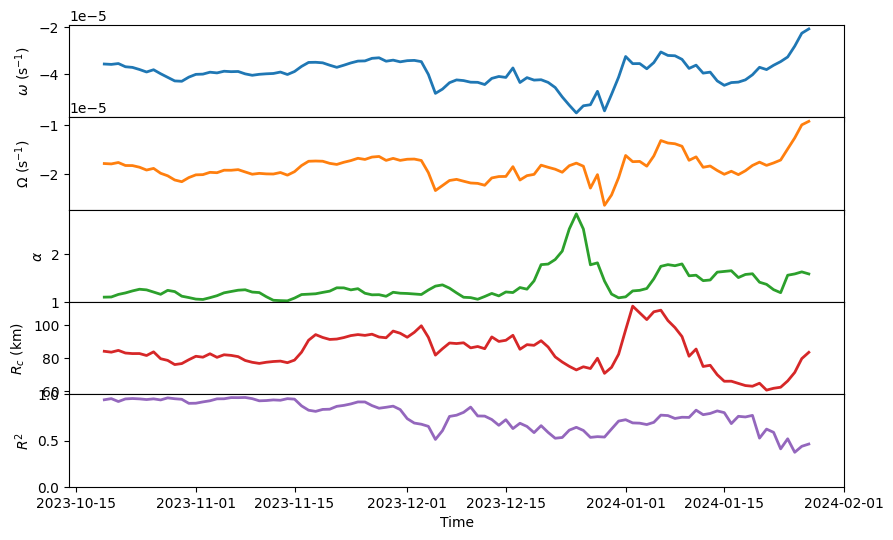

In [11]:
# Time series 
clrs = plt.colormaps['tab10']
fig, axs = plt.subplots(5, 1, figsize=(10,6), sharex=True)
lw = 2

axs[0].plot(df_res.time, df_res.w, color=clrs(0), lw=lw)
axs[0].set_ylabel(r'$\omega$ (s$^{-1}$)')

axs[1].plot(df_res.time, df_res.Omega, color=clrs(1), lw=lw)
axs[1].set_ylabel(r'$\Omega$ (s$^{-1}$)')

axs[2].plot(df_res.time, df_res.alpha, color=clrs(2), lw=lw)
axs[2].set_ylabel(r'$\alpha$')
axs[2].set_ylim(1, None)

axs[3].plot(df_res.time, df_res.Rc/1e3, color=clrs(3), lw=lw)
axs[3].set_ylabel(r'$R_c$ (km)')

axs[4].plot(df_res.time, df_res.R2, color=clrs(4), lw=lw)
axs[4].set_ylabel(r'$R^2$')
axs[4].set_xlabel('Time')
axs[4].set_ylim(0,1)

fig.subplots_adjust(hspace=0)
